# PEAD Further Analysis — v4 Clean
## OLS → Logistic (60d + 20d) → EN Logistic (60d + 20d) → Neural Net (60d + 20d)

**Targets:** `CAR_2_60`, `CAR_2_20`  
**Sample:** S&P 500 firms, 2012–2024  
**Split:** Walk-forward — train ≤ 2020, test > 2020  

Following Ng et al. (2008) for OLS baseline and Meursault et al. (2023) for the logistic/elastic net framework.

In [ ]:
# ── Imports ───────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import yfinance as yf
import statsmodels.api as sm
from scipy import stats
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
from sklearn.model_selection import GridSearchCV, StratifiedKFold

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
plt.rcParams['figure.dpi'] = 120
print('Imports done.')

Imports done.


## 1. Load Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

path = "/content/drive/MyDrive/ibes_df_final.csv" # Assuming the file is in the root of MyDrive
ibes_df = pd.read_csv(path, low_memory=False)
ibes_df["anndats"] = pd.to_datetime(ibes_df["anndats"])
ibes_df.head()

,oftic,anndats,FISCALP,actual,surpmean,surpstdev,suescore,stock_ret_next,mkt_ret_next,excess_ret_next,...,vwretd,swbeta,ivol,tvol,McapRank,TurnRank,VolatilityRank,PriceRank,public_date,de_ratio
0,A,2012-02-15,QTR,0.69,0.68800,0.01207,0.16569,0.004354,0.011026,-0.006672,...,-0.97%,1.59,0.0140,2.07%,10.0,7.0,5.0,9.0,2012-01-31,1.101
1,A,2012-05-14,QTR,0.78,0.73062,0.00866,5.70525,0.041388,-0.005746,0.047134,...,0.18%,1.55,0.0137,1.92%,10.0,9.0,4.0,9.0,2012-04-30,1.096
2,A,2012-08-15,QTR,0.79,0.82859,0.01692,-2.28022,-0.082263,0.007101,-0.089363,...,-1.16%,1.56,0.0142,2.06%,10.0,9.0,7.0,9.0,2012-07-31,1.049
3,A,2012-11-19,QTR,0.86,0.79963,0.01810,3.33582,-0.032792,0.000663,-0.033455,...,0.62%,1.54,0.0134,1.89%,10.0,10.0,3.0,9.0,2012-10-31,1.028
4,A,2013-02-14,QTR,0.63,0.66753,0.01325,-2.83270,-0.052266,-0.001045,-0.051221,...,-0.36%,1.11,0.0119,1.42%,10.0,9.0,3.0,9.0,2013-01-31,1.033


## 2. Macro Features + Data Prep

In [ ]:
drop_cols = ['vwretd', 'public_date', 'FISCALP', 'cal_q', 'qtr']
ibes_df   = ibes_df.drop(columns=[c for c in drop_cols if c in ibes_df.columns])

macro_start = str((ibes_df['anndats'].min() - pd.Timedelta(days=10)).date())
macro_end   = str((ibes_df['anndats'].max() + pd.Timedelta(days=10)).date())

macro_raw = yf.download(
    ['^VIX', '^TNX', '^GSPC'],
    start=macro_start, end=macro_end,
    auto_adjust=True, progress=False
)['Close']
macro_raw.index = pd.to_datetime(macro_raw.index)
spx_mom = macro_raw['^GSPC'].pct_change().rolling(63).sum()

ibes_df['vix_t']      = ibes_df['anndats'].apply(lambda d: macro_raw['^VIX'].asof(pd.Timestamp(d)))
ibes_df['tsy_10y']    = ibes_df['anndats'].apply(lambda d: macro_raw['^TNX'].asof(pd.Timestamp(d)))
ibes_df['spx_mom_3m'] = ibes_df['anndats'].apply(lambda d: spx_mom.asof(pd.Timestamp(d)))

cols = [
    'suescore', 'swbeta', 'ivol', 'de_ratio',
    'McapRank', 'TurnRank', 'VolatilityRank', 'PriceRank',
    'vix_t', 'tsy_10y', 'spx_mom_3m',
]

ibes_df[cols] = ibes_df[cols].apply(pd.to_numeric, errors='coerce')
ibes_df[cols] = ibes_df[cols].replace([np.inf, -np.inf], np.nan)
ibes_df['pos_drift']    = (ibes_df['CAR_2_60'] > 0).astype(int)
ibes_df['pos_drift_20'] = (ibes_df['CAR_2_20'] > 0).astype(int)

ml_df = ibes_df[
    cols + ['CAR_2_60', 'CAR_2_20', 'pos_drift', 'pos_drift_20', 'anndats', 'year', 'SUE_q']
].copy().dropna()

print(f'ML dataset ready: {len(ml_df):,} rows, {len(cols)} features')
print(f'Years: {ml_df.year.min()} – {ml_df.year.max()}')

ML dataset ready: 20,341 rows, 11 features
Years: 2012 – 2024


## 3. Walk-Forward Train / Test Split

In [ ]:
train = ml_df[ml_df['year'] <= 2020].copy()
test  = ml_df[ml_df['year'] >  2020].copy()

print(f'Train: {len(train):,} rows ({train.year.min()}–{train.year.max()})')
print(f'Test:  {len(test):,} rows  ({test.year.min()}–{test.year.max()})')
print(f'\nTrain pos_drift rate:    {train.pos_drift.mean():.3f}')
print(f'Train pos_drift_20 rate: {train.pos_drift_20.mean():.3f}')

X_train = train[cols]
X_test  = test[cols]

Train: 13,415 rows (2012–2020)
Test:  6,926 rows  (2021–2024)

Train pos_drift rate:    0.545
Train pos_drift_20 rate: 0.527


## 4. Descriptive analysis plots


  DESCRIPTIVE ANALYSIS

─────────────────────────────────────────────────────────────────
1. SUMMARY STATISTICS
─────────────────────────────────────────────────────────────────

──────────────────────────────
  TRAINING SET  2012–2020  (N = 13,415 obs)
──────────────────────────────
                      N     Mean       Std        Min      P25   Median      P75        Max
suescore        13415.0   1.7742    4.0662   -34.1555   0.0884   1.2685   2.9295   160.8200
swbeta          13415.0   1.0704    0.5267    -0.8200   0.7500   1.0300   1.3300     6.1500
ivol            13415.0   0.0145    0.0076     0.0019   0.0096   0.0122   0.0171     0.0976
de_ratio        13415.0   0.9947  118.5812 -9243.9000   0.9140   1.7070   3.2335  1818.1000
McapRank        13415.0   9.6024    0.7738     2.0000   9.0000  10.0000  10.0000    10.0000
TurnRank        13415.0   8.1426    1.7130     1.0000   7.0000   9.0000  10.0000    10.0000
VolatilityRank  13415.0   5.2924    2.4130     1.0000   3.0000   5.0000

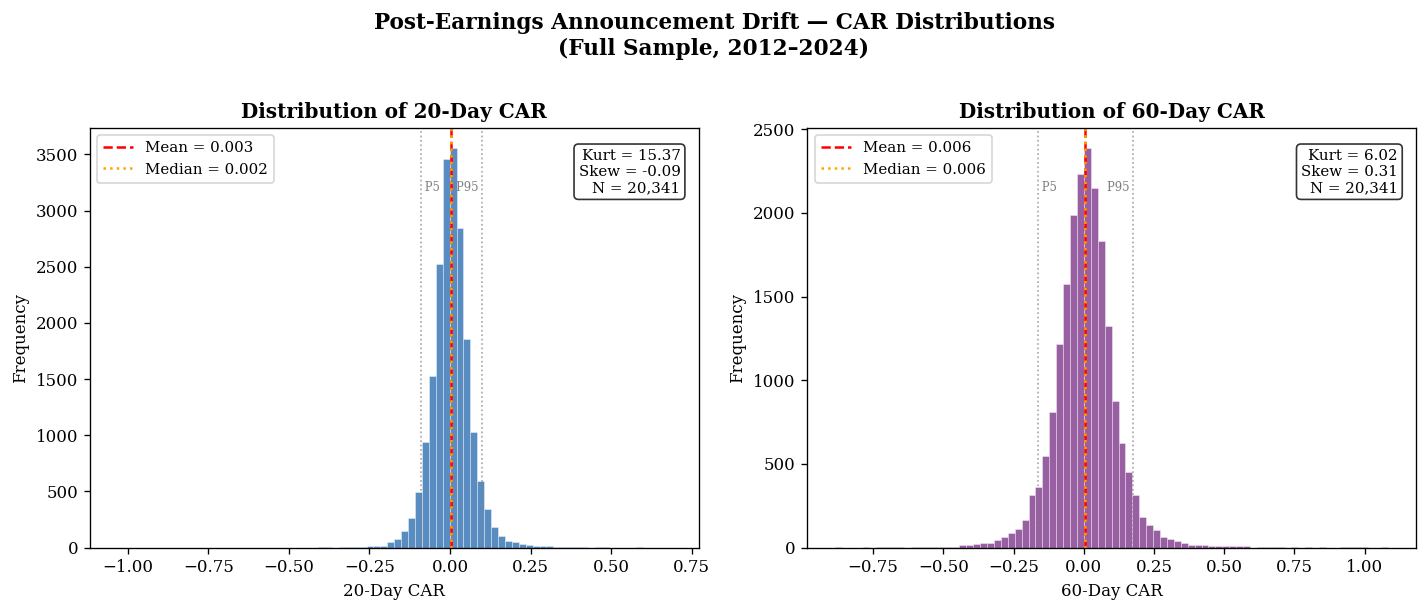


CAR_2_20:  mean=0.0034  median=0.0022  std=0.0646  skew=-0.086  kurt=15.368

CAR_2_60:  mean=0.0059  median=0.0062  std=0.1108  skew=0.314  kurt=6.024

─────────────────────────────────────────────────────────────────
3. SUE QUINTILE TABLE  (Bernard & Thomas, 1989)
─────────────────────────────────────────────────────────────────

CAR_2_60:
                 N  Mean CAR  t-stat  p-value  Sig
SUE Quintile                                      
1             3970    0.0052   2.674   0.0075  ***
2             4122    0.0051   2.939   0.0033  ***
3             4083    0.0047   2.722   0.0065  ***
4             4111    0.0059   3.590   0.0003  ***
5             4055    0.0088   5.425   0.0000  ***

CAR_2_20:
                 N  Mean CAR  t-stat  p-value  Sig
SUE Quintile                                      
1             3970    0.0024   2.051   0.0404   **
2             4122    0.0027   2.717   0.0066  ***
3             4083    0.0030   2.967   0.0030  ***
4             4111    0.0031   3.

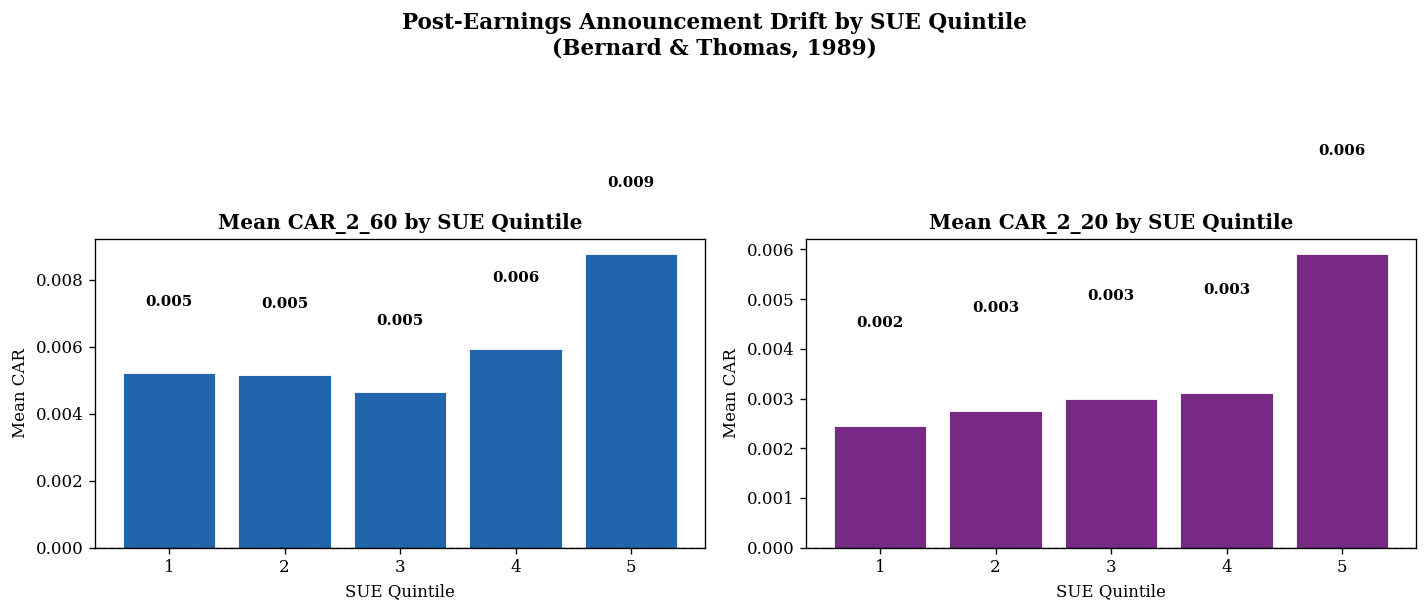


─────────────────────────────────────────────────────────────────
5. CORRELATION MATRIX HEATMAP
─────────────────────────────────────────────────────────────────

Correlation matrix:
                suescore  swbeta  ivol  de_ratio  McapRank  TurnRank  VolatilityRank  PriceRank  vix_t  tsy_10y  spx_mom_3m
suescore            1.00    0.01  0.00     -0.01      0.02     -0.01           -0.03       0.10   0.01     0.01        0.03
swbeta              0.01    1.00  0.35     -0.00     -0.17      0.26            0.24      -0.19   0.03    -0.12        0.00
ivol                0.00    0.35  1.00     -0.01     -0.28      0.19            0.22      -0.22   0.30    -0.18        0.02
de_ratio           -0.01   -0.00 -0.01      1.00      0.00     -0.01           -0.00      -0.01  -0.00     0.01       -0.01
McapRank            0.02   -0.17 -0.28      0.00      1.00     -0.10           -0.20       0.36   0.05     0.07       -0.01
TurnRank           -0.01    0.26  0.19     -0.01     -0.10      1.00    

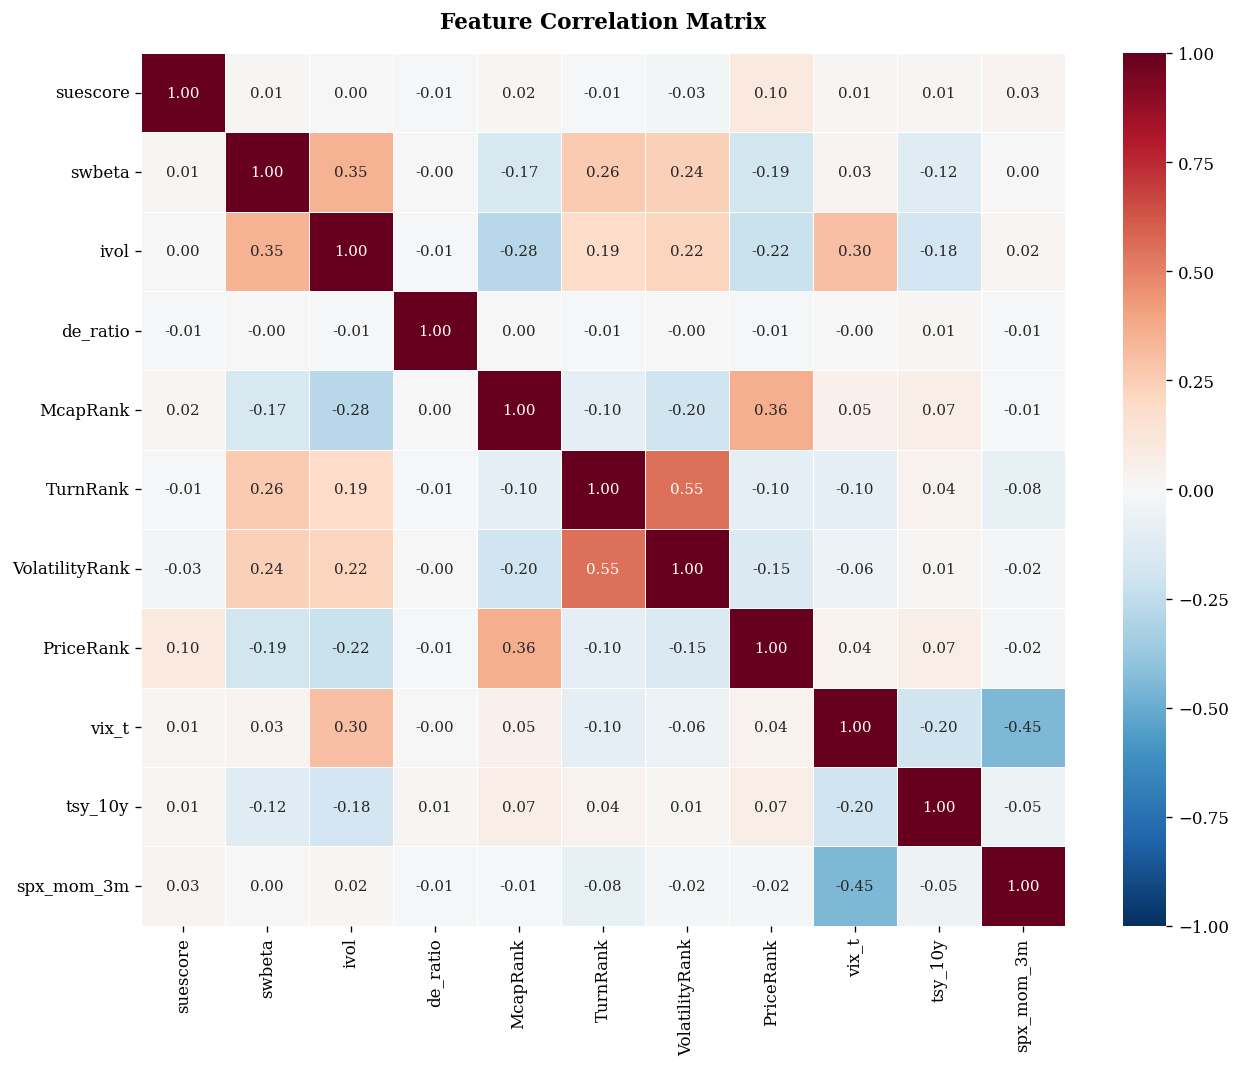


─────────────────────────────────────────────────────────────────
6. POSITIVE DRIFT RATE BY YEAR
─────────────────────────────────────────────────────────────────

Proportion of firms with positive CAR_2_60 by year:
year
2012    0.5786
2013    0.5596
2014    0.5485
2015    0.5379
2016    0.5598
2017    0.5637
2018    0.5453
2019    0.5034
2020    0.5215
2021    0.5357
2022    0.5903
2023    0.4305
2024    0.4326


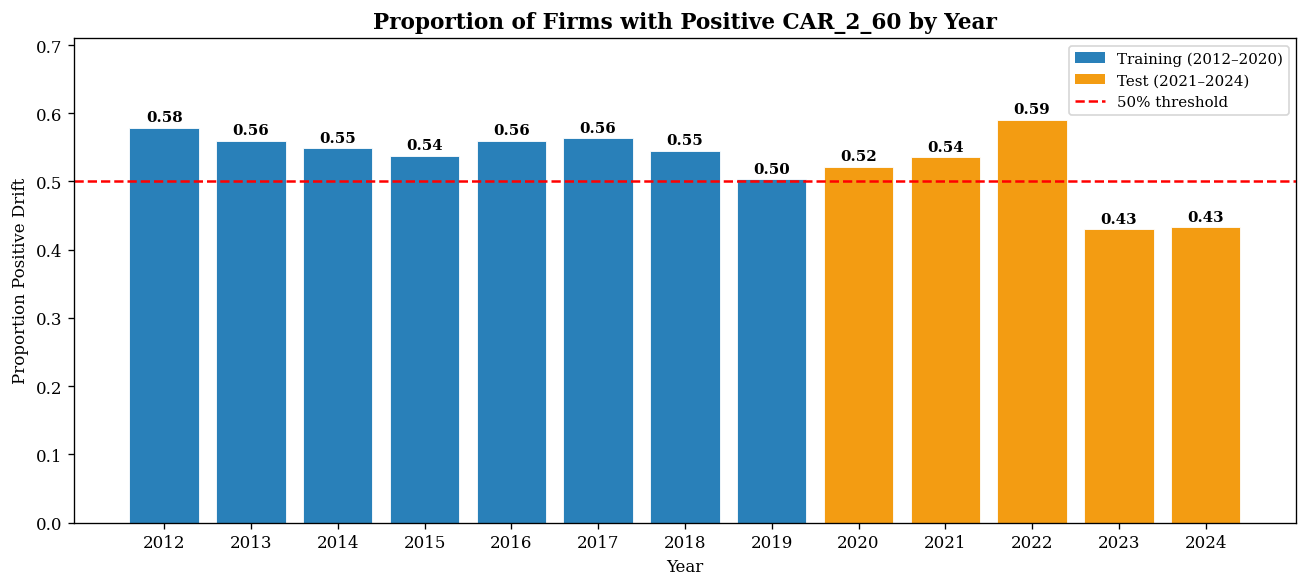

In [ ]:
# ============================================================
# DESCRIPTIVE ANALYSIS SECTION — PEAD Project
# Insert after cell 3 (Walk-Forward Split) and before cell 4
# (SUE Quintile Analysis) so all variables are defined.
#
# Requires (already defined by that point):
#   ml_df, train, test, cols
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'serif'

print("=" * 65)
print("  DESCRIPTIVE ANALYSIS")
print("=" * 65)


# ============================================================
# 1. SUMMARY STATISTICS TABLE
# Separate for train (≤2020) and test (>2020)
# ============================================================
print("\n" + "─" * 65)
print("1. SUMMARY STATISTICS")
print("─" * 65)

summary_vars = cols + ['CAR_2_60', 'CAR_2_20']

def summary_stats(df, label):
    s = df[summary_vars].describe().T[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']]
    s.columns = ['N', 'Mean', 'Std', 'Min', 'P25', 'Median', 'P75', 'Max']
    s = s.round(4)
    print(f"\n{'─'*30}")
    print(f"  {label}  (N = {len(df):,} obs)")
    print(f"{'─'*30}")
    print(s.to_string())
    return s

train_years = f"{train['year'].min()}–{train['year'].max()}"
test_years  = f"{test['year'].min()}–{test['year'].max()}"

stats_train = summary_stats(train, f"TRAINING SET  {train_years}")
stats_test  = summary_stats(test,  f"TEST SET       {test_years}")

# Side-by-side mean comparison
train_mean = stats_train['Mean']
test_mean  = stats_test['Mean']
delta      = (test_mean - train_mean).round(4)
pct_change = ((test_mean - train_mean) / train_mean.abs() * 100).round(2)

mean_compare = pd.DataFrame({
    f'Train Mean ({train_years})': train_mean,
    f'Test Mean  ({test_years})':  test_mean,
    'Δ Mean':                      delta,
    '% Change':                    pct_change.map('{:+.2f}%'.format)
})
print("\n\nMEAN COMPARISON (Train vs Test):")
print(mean_compare.to_string())


# ============================================================
# 2. CAR DISTRIBUTION PLOTS
# Histograms of CAR_2_20 and CAR_2_60 with fat-tail annotation
# ============================================================
print("\n" + "─" * 65)
print("2. CAR DISTRIBUTION PLOTS")
print("─" * 65)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col, label, color in zip(
    axes,
    ['CAR_2_20', 'CAR_2_60'],
    ['20-Day CAR', '60-Day CAR'],
    ['#2166ac', '#762a83']
):
    data = ml_df[col].dropna()
    kurt = data.kurt()
    skew = data.skew()

    ax.hist(data, bins=80, color=color, alpha=0.75, edgecolor='white', linewidth=0.3)
    ax.axvline(data.mean(),   color='red',    ls='--', lw=1.5, label=f'Mean = {data.mean():.3f}')
    ax.axvline(data.median(), color='orange', ls=':',  lw=1.5, label=f'Median = {data.median():.3f}')
    ax.set_title(f'Distribution of {label}', fontweight='bold', fontsize=12)
    ax.set_xlabel(label)
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=9)
    ax.text(0.97, 0.95,
            f'Kurt = {kurt:.2f}\nSkew = {skew:.2f}\nN = {len(data):,}',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=9, bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8))

    # Mark 5th/95th percentile to show fat tails
    p5, p95 = data.quantile(0.05), data.quantile(0.95)
    ax.axvline(p5,  color='grey', ls=':', lw=1, alpha=0.7)
    ax.axvline(p95, color='grey', ls=':', lw=1, alpha=0.7)
    ax.text(p5,  ax.get_ylim()[1]*0.85, ' P5',  fontsize=7, color='grey')
    ax.text(p95, ax.get_ylim()[1]*0.85, 'P95 ', fontsize=7, color='grey', ha='right')

plt.suptitle('Post-Earnings Announcement Drift — CAR Distributions\n(Full Sample, 2012–2024)',
             fontweight='bold', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

for col in ['CAR_2_20', 'CAR_2_60']:
    d = ml_df[col].dropna()
    print(f"\n{col}:  mean={d.mean():.4f}  median={d.median():.4f}  "
          f"std={d.std():.4f}  skew={d.skew():.3f}  kurt={d.kurt():.3f}")


# ============================================================
# 3. SUE QUINTILE TABLE
# Mean CAR by SUE quintile with t-stats and p-values
# ============================================================
print("\n" + "─" * 65)
print("3. SUE QUINTILE TABLE  (Bernard & Thomas, 1989)")
print("─" * 65)

rows = []
for q in [1, 2, 3, 4, 5]:
    grp = ml_df[ml_df['SUE_q'] == q]
    for target in ['CAR_2_60', 'CAR_2_20']:
        mean_val = grp[target].mean()
        # t-test vs zero (H0: mean CAR = 0)
        t, p = stats.ttest_1samp(grp[target].dropna(), 0)
        rows.append({
            'SUE Quintile': q,
            'Target': target,
            'N': len(grp),
            'Mean CAR': round(mean_val, 4),
            't-stat': round(t, 3),
            'p-value': round(p, 4),
            'Sig': '***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.10 else ''))
        })

sue_table = pd.DataFrame(rows)

# Pivot for clean display
for target in ['CAR_2_60', 'CAR_2_20']:
    sub = sue_table[sue_table['Target'] == target][
        ['SUE Quintile', 'N', 'Mean CAR', 't-stat', 'p-value', 'Sig']
    ].set_index('SUE Quintile')
    print(f"\n{target}:")
    print(sub.to_string())

# Q5–Q1 spreads (replicating notebook's ttest_ind)
for target in ['CAR_2_60', 'CAR_2_20']:
    q5 = ml_df[ml_df['SUE_q'] == 5][target]
    q1 = ml_df[ml_df['SUE_q'] == 1][target]
    spread = q5.mean() - q1.mean()
    t, p   = stats.ttest_ind(q5, q1, nan_policy='omit')
    print(f"\n{target}  Q5–Q1 spread = {spread:.4f}  t = {t:.3f}  p = {p:.4f}")

# Bar chart — mean CAR by SUE quintile
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)
for ax, target, color in zip(axes, ['CAR_2_60', 'CAR_2_20'], ['#2166ac', '#762a83']):
    means = ml_df.groupby('SUE_q')[target].mean()
    colors = ['#d73027' if v < 0 else color for v in means]
    ax.bar(means.index.astype(str), means.values, color=colors, edgecolor='white', linewidth=0.5)
    ax.axhline(0, color='black', lw=0.8, ls='--')
    ax.set_title(f'Mean {target} by SUE Quintile', fontweight='bold')
    ax.set_xlabel('SUE Quintile')
    ax.set_ylabel('Mean CAR')
    for i, (idx, val) in enumerate(means.items()):
        ax.text(i, val + (0.002 if val >= 0 else -0.003),
                f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Post-Earnings Announcement Drift by SUE Quintile\n(Bernard & Thomas, 1989)',
             fontweight='bold', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()




# ============================================================
# 4. CORRELATION MATRIX HEATMAP
# Justifies elastic net — correlated features make OLS unreliable
# ============================================================
print("\n" + "─" * 65)
print("5. CORRELATION MATRIX HEATMAP")
print("─" * 65)

corr = ml_df[cols].corr().round(2)
print("\nCorrelation matrix:")
print(corr.to_string())

# Pairs with |r| > 0.3
print("\nHigh correlations (|r| > 0.30):")
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        r = corr.iloc[i, j]
        if abs(r) > 0.30:
            print(f"  {corr.columns[i]:20s} × {corr.columns[j]:20s}  r = {r:.3f}")

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = False   # show full matrix
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    annot_kws={'size': 9},
    ax=ax
)
ax.set_title('Feature Correlation Matrix', fontweight='bold', fontsize=13, pad=15)
plt.tight_layout()
plt.show()


# ============================================================
# 5. POSITIVE DRIFT RATE BY YEAR
# Note 2020 exclusion from training, post-2021 test period
# ============================================================
print("\n" + "─" * 65)
print("6. POSITIVE DRIFT RATE BY YEAR")
print("─" * 65)

drift_by_year = ml_df.groupby('year')['pos_drift'].mean()
print("\nProportion of firms with positive CAR_2_60 by year:")
print(drift_by_year.round(4).to_string())

fig, ax = plt.subplots(figsize=(11, 5))
colors = []
for yr in drift_by_year.index:
    if yr >= 2020:
        colors.append('#f39c12')     # amber — test period
    else:
        colors.append('#2980b9')     # blue — training period

bars = ax.bar(drift_by_year.index.astype(str), drift_by_year.values,
              color=colors, edgecolor='white', linewidth=0.5)
ax.axhline(0.5, color='red', ls='--', lw=1.5, label='50% threshold')

# Train / test / 2020 legend patches
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2980b9', label=f'Training ({train_years[:-4]}2020)'),
    Patch(facecolor='#f39c12', label=f'Test ({test_years})'),
]
ax.legend(handles=legend_elements + [plt.Line2D([0],[0], color='red', ls='--', label='50% threshold')],
          fontsize=9)

# Annotate each bar
for bar, val in zip(bars, drift_by_year.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title('Proportion of Firms with Positive CAR_2_60 by Year',
             fontweight='bold', fontsize=13)
ax.set_ylabel('Proportion Positive Drift')
ax.set_xlabel('Year')
ax.set_ylim(0, min(1.0, drift_by_year.max() + 0.12))
plt.tight_layout()
plt.show()

## 4. Helper Functions

In [ ]:
def quintile_spread(test_df, proba, target, label):
    df = test_df[[target]].copy()
    df['proba'] = proba
    df['q']     = pd.qcut(df['proba'], 5, labels=[1,2,3,4,5])
    q5 = df[df['q']==5][target]
    q1 = df[df['q']==1][target]
    spread = q5.mean() - q1.mean()
    t, p   = stats.ttest_ind(q5, q1, nan_policy='omit')
    print(f'  [{label} → {target}]  Q5-Q1={spread:.4f}  t={t:.2f}  p={p:.4f}')
    return {'spread': spread, 't': t, 'p': p, 'df': df}

def plot_spread(res, target, title):
    df     = res['df']
    means  = df.groupby('q')[target].mean()
    colors = ['#d73027' if v < 0 else '#1a9850' for v in means]
    fig, ax = plt.subplots(figsize=(7,4))
    ax.bar(means.index.astype(str), means.values, color=colors, edgecolor='white')
    ax.axhline(0, color='black', lw=0.8, ls='--')
    ax.set_title(f'{title}  —  {target}', fontweight='bold')
    ax.set_xlabel(f'Predicted Probability Quintile   (Q5–Q1={res["spread"]:.3f}, p={res["p"]:.3f})')
    ax.set_ylabel('Mean Actual CAR')
    plt.tight_layout()
    plt.show()

def engineer_features(df, cols):
    X = df[cols].copy()
    X['sue_x_mcap'] = X['suescore'] * X['McapRank']
    X['sue_x_ivol'] = X['suescore'] * X['ivol']
    X['sue_x_turn'] = X['suescore'] * X['TurnRank']
    X['sue_x_beta'] = X['suescore'] * X['swbeta']
    X['sue_x_vix']  = X['suescore'] * X['vix_t']
    X['sue_x_spx']  = X['suescore'] * X['spx_mom_3m']
    return X

print('Helper functions defined.')

Helper functions defined.


## 5. SUE Quintile Analysis

In [ ]:
pead_table = test.groupby('SUE_q')[['CAR_2_60', 'CAR_2_20']].mean()
print('Mean CAR by SUE quintile (test period 2021–2024):')
print(pead_table.round(4))

for target in ['CAR_2_60', 'CAR_2_20']:
    q5 = test[test['SUE_q']==5][target]
    q1 = test[test['SUE_q']==1][target]
    spread = q5.mean() - q1.mean()
    t, p   = stats.ttest_ind(q5, q1, nan_policy='omit')
    print(f'\n{target} spread (Q5-Q1): {spread:.4f}  t={t:.2f}  p={p:.4f}')

Mean CAR by SUE quintile (test period 2021–2024):
       CAR_2_60  CAR_2_20
SUE_q                    
1        0.0017    0.0020
2       -0.0006    0.0018
3       -0.0028    0.0021
4        0.0013    0.0043
5        0.0021    0.0020

CAR_2_60 spread (Q5-Q1): 0.0005  t=0.10  p=0.9218

CAR_2_20 spread (Q5-Q1): 0.0001  t=0.02  p=0.9825


## 6. ANOVA

In [ ]:
for target in ['CAR_2_60', 'CAR_2_20']:
    groups = [test[test['SUE_q']==q][target].dropna() for q in [1,2,3,4,5]]
    f, p   = stats.f_oneway(*groups)
    print(f'One-way ANOVA — {target}: F={f:.3f}  p={p:.4f}')

One-way ANOVA — CAR_2_60: F=0.409  p=0.8024
One-way ANOVA — CAR_2_20: F=0.339  p=0.8518


## 7. OLS — Baseline (Full Sample for Interpretation)

In [ ]:
X_full = sm.add_constant(ml_df[cols])

print('=' * 60)
print('OLS — CAR_2_60 ~ all predictors (HC1 robust SEs, full sample)')
print('=' * 60)
ols = sm.OLS(ml_df['CAR_2_60'], X_full).fit(cov_type='HC1')
print(ols.summary())

print('\n' + '=' * 60)
print('OLS — CAR_2_20 ~ all predictors (HC1 robust SEs, full sample)')
print('=' * 60)
ols_20 = sm.OLS(ml_df['CAR_2_20'], X_full).fit(cov_type='HC1')
print(ols_20.summary())

OLS — CAR_2_60 ~ all predictors (HC1 robust SEs, full sample)
                            OLS Regression Results                            
Dep. Variable:               CAR_2_60   R-squared:                       0.019
Model:                            OLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                     20.34
Date:                Wed, 24 Jun 2026   Prob (F-statistic):           1.47e-41
Time:                        13:29:56   Log-Likelihood:                 16078.
No. Observations:               20341   AIC:                        -3.213e+04
Df Residuals:                   20329   BIC:                        -3.204e+04
Df Model:                          11                                         
Covariance Type:                  HC1                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------

## 8. Logistic Regression — Full Sample (Coefficient Interpretation Only)

In [ ]:
print('=' * 60)
print('Logistic — FULL SAMPLE — pos_drift (CAR_2_60 > 0)')
print('NOTE: Interpretation only. Not used for prediction.')
print('=' * 60)
logit_full = sm.Logit(
    (ml_df['CAR_2_60'] > 0).astype(int),
    sm.add_constant(ml_df[cols])
).fit()
print(logit_full.summary())

Logistic — FULL SAMPLE — pos_drift (CAR_2_60 > 0)
NOTE: Interpretation only. Not used for prediction.
Optimization terminated successfully.
         Current function value: 0.687393
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:               CAR_2_60   No. Observations:                20341
Model:                          Logit   Df Residuals:                    20329
Method:                           MLE   Df Model:                           11
Date:                Wed, 24 Jun 2026   Pseudo R-squ.:                0.005997
Time:                        13:29:59   Log-Likelihood:                -13982.
converged:                       True   LL-Null:                       -14067.
Covariance Type:            nonrobust   LLR p-value:                 2.182e-30
                     coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------

## 9. Logistic Regression — Train Only (Out-of-Sample Evaluation)
### 9a. 60-Day Horizon

In [ ]:
print('=' * 60)
print('Logistic — TRAIN ONLY — pos_drift (CAR_2_60 > 0)')
print('=' * 60)
logit_60 = sm.Logit(train['pos_drift'], sm.add_constant(X_train)).fit()
print(logit_60.summary())

logit_60_proba = logit_60.predict(sm.add_constant(X_test))
print('\nLong-Short Spread:')
logit_60_res = quintile_spread(test, logit_60_proba, 'CAR_2_60', 'Logistic (60-day)')
print(f'\nAUC-ROC: {roc_auc_score(test["pos_drift"], logit_60_proba):.4f}')
preds = (logit_60_proba > 0.5).astype(int)
print(f'Accuracy: {accuracy_score(test["pos_drift"], preds):.4f}')

Logistic — TRAIN ONLY — pos_drift (CAR_2_60 > 0)
Optimization terminated successfully.
         Current function value: 0.686572
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:              pos_drift   No. Observations:                13415
Model:                          Logit   Df Residuals:                    13403
Method:                           MLE   Df Model:                           11
Date:                Wed, 24 Jun 2026   Pseudo R-squ.:                0.003757
Time:                        13:30:03   Log-Likelihood:                -9210.4
converged:                       True   LL-Null:                       -9245.1
Covariance Type:            nonrobust   LLR p-value:                 1.539e-10
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const              1.1160      0.308      3.624    

### 9b. 20-Day Horizon

In [ ]:
print('=' * 60)
print('Logistic — TRAIN ONLY — pos_drift_20 (CAR_2_20 > 0)')
print('=' * 60)
logit_20 = sm.Logit(train['pos_drift_20'], sm.add_constant(X_train)).fit()
print(logit_20.summary())

logit_20_proba = logit_20.predict(sm.add_constant(X_test))
print('\nLong-Short Spread:')
logit_20_res = quintile_spread(test, logit_20_proba, 'CAR_2_20', 'Logistic (20-day)')
print(f'\nAUC-ROC: {roc_auc_score(test["pos_drift_20"], logit_20_proba):.4f}')
preds = (logit_20_proba > 0.5).astype(int)
print(f'Accuracy: {accuracy_score(test["pos_drift_20"], preds):.4f}')

Logistic — TRAIN ONLY — pos_drift_20 (CAR_2_20 > 0)
Optimization terminated successfully.
         Current function value: 0.688253
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:           pos_drift_20   No. Observations:                13415
Model:                          Logit   Df Residuals:                    13403
Method:                           MLE   Df Model:                           11
Date:                Wed, 24 Jun 2026   Pseudo R-squ.:                0.004894
Time:                        13:30:06   Log-Likelihood:                -9232.9
converged:                       True   LL-Null:                       -9278.3
Covariance Type:            nonrobust   LLR p-value:                 1.155e-14
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.7507      0.306      2.456 

## 10. Elastic Net Logistic Regression
### 10a. 60-Day Horizon (pos_drift)

EN Logistic — pos_drift (CAR_2_60 > 0)
C=0.01, l1_ratio=0.5 — original 11 features

Non-zero: 5/11
Zeroed:   ['ivol', 'de_ratio', 'PriceRank', 'vix_t', 'tsy_10y', 'spx_mom_3m']
       feature    coef
      McapRank -0.0911
      TurnRank  0.0554
VolatilityRank -0.0317
        swbeta  0.0146
      suescore  0.0134

AUC-ROC:  0.5192
Accuracy: 0.5131
              precision    recall  f1-score   support

   Neg drift       0.51      0.74      0.60      3485
   Pos drift       0.52      0.28      0.37      3441

    accuracy                           0.51      6926
   macro avg       0.51      0.51      0.49      6926
weighted avg       0.51      0.51      0.49      6926


Long-Short Spread:
  [EN Logistic (60-day) → CAR_2_60]  Q5-Q1=0.0234  t=5.18  p=0.0000


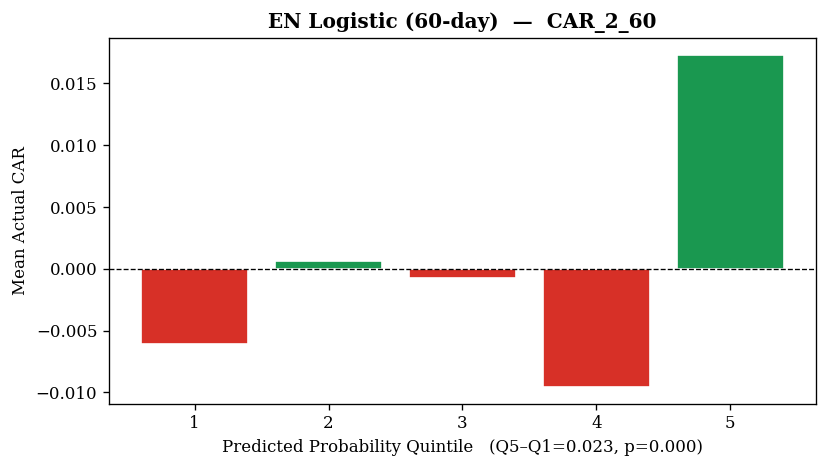

In [ ]:
# ── EN Logistic — 60-day (pos_drift = CAR_2_60 > 0) ──────────────────
print('=' * 60)
print('EN Logistic — pos_drift (CAR_2_60 > 0)')
print('C=0.01, l1_ratio=0.5 — original 11 features')
print('=' * 60)

y_train_60 = train['pos_drift'].astype(int)
y_test_60  = test['pos_drift'].astype(int)

en_60 = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(
        penalty='elasticnet', solver='saga',
        max_iter=10000, random_state=SEED,
        class_weight='balanced',
        C=0.01, l1_ratio=0.5
    ))
])
en_60.fit(X_train, y_train_60)

coef_60 = pd.DataFrame({'feature': cols,
                         'coef': en_60.named_steps['model'].coef_[0]})\
            .sort_values('coef', key=abs, ascending=False)
print(f'\nNon-zero: {(coef_60.coef!=0).sum()}/{len(coef_60)}')
print(f'Zeroed:   {list(coef_60[coef_60.coef==0].feature)}')
print(coef_60[coef_60.coef!=0].round(4).to_string(index=False))

proba_en_60 = en_60.predict_proba(X_test)[:,1]
print(f'\nAUC-ROC:  {roc_auc_score(y_test_60, proba_en_60):.4f}')
print(f'Accuracy: {accuracy_score(y_test_60, en_60.predict(X_test)):.4f}')
print(classification_report(y_test_60, en_60.predict(X_test),
      target_names=['Neg drift','Pos drift']))

print('\nLong-Short Spread:')
en_res_60 = quintile_spread(test, proba_en_60, 'CAR_2_60', 'EN Logistic (60-day)')
plot_spread(en_res_60, 'CAR_2_60', 'EN Logistic (60-day)')

## 11. Neural Network (Optuna + Ensemble)
### 11a. 60-Day Horizon

In [ ]:
X_train_eng = engineer_features(train, cols)
X_test_eng  = engineer_features(test,  cols)

In [ ]:
!pip install optuna -q
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 6.9 MB/s eta 0:00:00


In [ ]:
def run_nn_experiment(y_train_target, y_test_target, target_col, label):
    """Run full neural net experiment for a given target."""
    print('=' * 60)
    print(f'Neural Network — {label}')
    print('=' * 60)

    scaler  = StandardScaler()
    X_tr_s  = scaler.fit_transform(X_train_eng)
    X_te_s  = scaler.transform(X_test_eng)

    y_tr_np = y_train_target.values.astype(np.float32)
    y_te_np = y_test_target.values.astype(np.float32)

    n_val   = max(int(len(X_tr_s) * 0.20), 150)
    X_val_s, y_val_np = X_tr_s[-n_val:], y_tr_np[-n_val:]
    X_tr_s,  y_tr_np  = X_tr_s[:-n_val], y_tr_np[:-n_val]

    def to_t(a): return torch.tensor(a, dtype=torch.float32)
    X_tr_t  = to_t(X_tr_s)
    X_val_t = to_t(X_val_s)
    y_val_t = to_t(y_val_np)
    X_te_t  = to_t(X_te_s)

    n_neg      = (y_tr_np == 0).sum()
    n_pos      = (y_tr_np == 1).sum()
    pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32)
    print(f'pos_weight: {pos_weight.item():.4f}  Train: {len(X_tr_s)}  Val: {len(X_val_s)}')

    class PEADNet(nn.Module):
        def __init__(self, n_features, hidden=(64,32,16), dropout=0.2):
            super().__init__()
            layers, in_dim = [], n_features
            for h in hidden:
                layers += [nn.Linear(in_dim,h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
                in_dim = h
            layers.append(nn.Linear(in_dim, 1))
            self.net = nn.Sequential(*layers)
        def forward(self, x): return self.net(x).squeeze(-1)
        def predict_proba(self, x):
            with torch.no_grad(): return torch.sigmoid(self.forward(x)).numpy()

    def train_model(hidden, dropout, lr, batch_size, weight_decay, label_smooth,
                    seed=42, max_epochs=200, patience=20):
        torch.manual_seed(seed)
        loader    = DataLoader(TensorDataset(X_tr_t, to_t(y_tr_np)),
                               batch_size=batch_size, shuffle=True)
        model     = PEADNet(len(X_train_eng.columns), hidden, dropout)
        optimiser = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimiser, T_max=max_epochs, eta_min=1e-6)
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        best_val, best_w, wait = np.inf, None, 0
        tr_losses, val_losses  = [], []
        for epoch in range(max_epochs):
            model.train()
            bl = []
            for xb, yb in loader:
                yb = yb * (1 - label_smooth) + 0.5 * label_smooth
                optimiser.zero_grad()
                criterion(model(xb), yb).backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimiser.step()
                bl.append(criterion(model(xb), yb).item())
            tr_losses.append(np.mean(bl))
            scheduler.step()
            model.eval()
            with torch.no_grad(): vl = criterion(model(X_val_t), y_val_t).item()
            val_losses.append(vl)
            if vl < best_val - 1e-6:
                best_val = vl
                best_w   = {k: v.clone() for k, v in model.state_dict().items()}
                wait     = 0
            else:
                wait += 1
                if wait >= patience:
                    print(f'  Early stop epoch {epoch+1} (best val: {best_val:.4f})')
                    break
        model.load_state_dict(best_w)
        return model, tr_losses, val_losses

    def objective(trial):
        hidden       = trial.suggest_categorical('hidden', [(64,32,16),(128,64,32),(64,32),(128,64)])
        dropout      = trial.suggest_float('dropout',      0.05, 0.4)
        lr           = trial.suggest_float('lr',           1e-4, 1e-2, log=True)
        batch_size   = trial.suggest_categorical('batch_size', [64,128,256])
        weight_decay = trial.suggest_float('weight_decay', 1e-6, 1e-2, log=True)
        label_smooth = trial.suggest_float('label_smooth', 0.0,  0.15)
        model, _, _  = train_model(hidden, dropout, lr, batch_size, weight_decay, label_smooth,
                                   seed=42, max_epochs=150, patience=15)
        model.eval()
        return roc_auc_score(y_val_np, model.predict_proba(X_val_t))

    print('\nRunning Optuna (100 trials)...')
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=100, show_progress_bar=True)
    print(f'Best val AUC: {study.best_value:.4f}')
    print(f'Best params:  {study.best_params}')

    p = study.best_params
    print(f'\nTraining ensemble of 5 models...')
    ensemble_probas, val_probas_list, tr_loss, val_loss = [], [], None, None
    for seed in range(5):
        model, trl, vll = train_model(
            p['hidden'], p['dropout'], p['lr'],
            p['batch_size'], p['weight_decay'], p['label_smooth'],
            seed=seed, max_epochs=300, patience=20
        )
        model.eval()
        proba     = model.predict_proba(X_te_t)
        val_proba = model.predict_proba(X_val_t)
        ensemble_probas.append(proba)
        val_probas_list.append(val_proba)
        print(f'  Seed {seed} — val AUC={roc_auc_score(y_val_np, val_proba):.4f}  '
              f'test AUC={roc_auc_score(y_te_np, proba):.4f}')
        if seed == 4: tr_loss, val_loss = trl, vll

    proba_ens  = np.mean(ensemble_probas, axis=0)
    val_proba_ens = np.mean(val_probas_list, axis=0)

    thresholds  = np.arange(0.35, 0.66, 0.01)
    val_accs    = [accuracy_score(y_val_np, (val_proba_ens > t).astype(int)) for t in thresholds]
    best_thresh = thresholds[np.argmax(val_accs)]
    preds_bin   = (proba_ens > best_thresh).astype(int)

    print(f'\nOptimal threshold: {best_thresh:.2f}')
    print(f'AUC-ROC:  {roc_auc_score(y_te_np, proba_ens):.4f}')
    print(f'Accuracy: {accuracy_score(y_te_np, preds_bin):.4f}')
    print(classification_report(y_te_np, preds_bin, target_names=['Neg drift','Pos drift']))

    print('\nLong-Short Spreads:')
    res_60 = quintile_spread(test, proba_ens, 'CAR_2_60', f'NN ({label})')
    res_20 = quintile_spread(test, proba_ens, 'CAR_2_20', f'NN ({label})')

    fig, ax = plt.subplots(figsize=(8,4))
    ax.plot(tr_loss,  label='Train', color='steelblue')
    ax.plot(val_loss, label='Val',   color='darkorange', ls='--')
    ax.set_title(f'Neural Net Training Curve — {label}', fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('BCE Loss'); ax.legend()
    plt.tight_layout(); plt.show()

    plot_spread(res_60, 'CAR_2_60', f'NN ({label})')
    plot_spread(res_20, 'CAR_2_20', f'NN ({label})')

    return proba_ens, res_60, res_20

print('run_nn_experiment function defined.')

run_nn_experiment function defined.


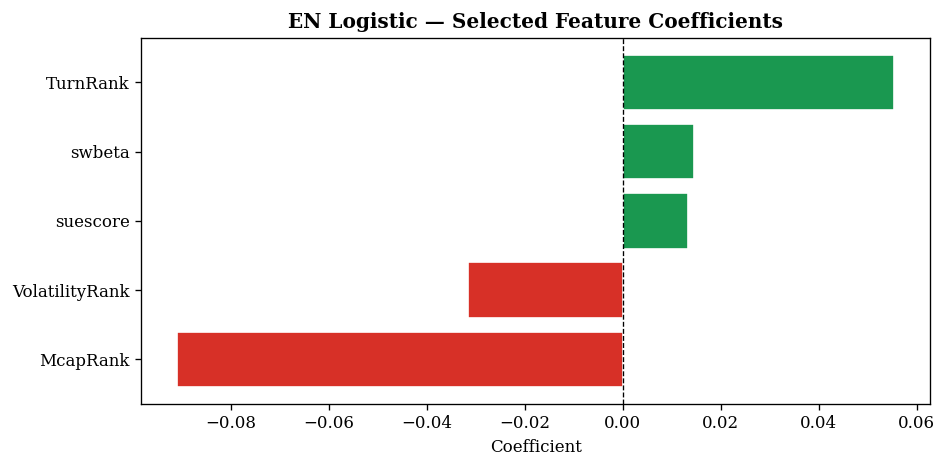

In [ ]:
# Feature importance bar chart
coef_nonzero = coef_60[coef_60.coef != 0].sort_values('coef')
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#d73027' if c < 0 else '#1a9850' for c in coef_nonzero.coef]
ax.barh(coef_nonzero.feature, coef_nonzero.coef, color=colors, edgecolor='white')
ax.axvline(0, color='black', lw=0.8, ls='--')
ax.set_title('EN Logistic — Selected Feature Coefficients', fontweight='bold')
ax.set_xlabel('Coefficient')
plt.tight_layout()
plt.show()

Neural Network — 60-day target
pos_weight: 0.8456  Train: 10732  Val: 2683

Running Optuna (100 trials)...


  0%|          | 0/100 [00:00<?, ?it/s]

  Early stop epoch 84 (best val: 0.6210)
  Early stop epoch 80 (best val: 0.6217)
  Early stop epoch 53 (best val: 0.6188)
  Early stop epoch 36 (best val: 0.6186)
  Early stop epoch 26 (best val: 0.6180)
  Early stop epoch 125 (best val: 0.6171)
  Early stop epoch 86 (best val: 0.6207)
  Early stop epoch 62 (best val: 0.6186)
  Early stop epoch 36 (best val: 0.6206)
  Early stop epoch 62 (best val: 0.6191)
  Early stop epoch 58 (best val: 0.6179)
  Early stop epoch 58 (best val: 0.6170)
  Early stop epoch 130 (best val: 0.6219)
  Early stop epoch 58 (best val: 0.6203)
  Early stop epoch 46 (best val: 0.6170)
  Early stop epoch 66 (best val: 0.6174)
  Early stop epoch 55 (best val: 0.6150)
  Early stop epoch 38 (best val: 0.6179)
  Early stop epoch 43 (best val: 0.6180)
  Early stop epoch 54 (best val: 0.6158)
  Early stop epoch 57 (best val: 0.6168)
  Early stop epoch 27 (best val: 0.6195)
  Early stop epoch 28 (best val: 0.6180)
  Early stop epoch 57 (best val: 0.6158)
  Early stop e

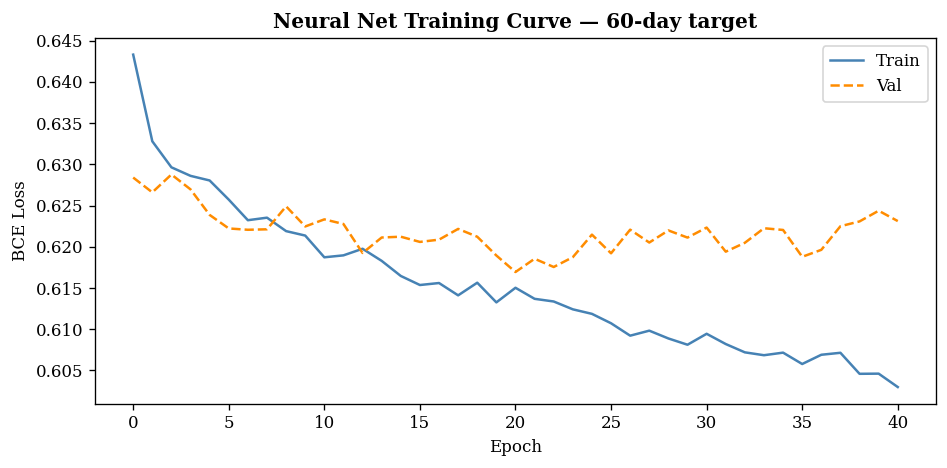

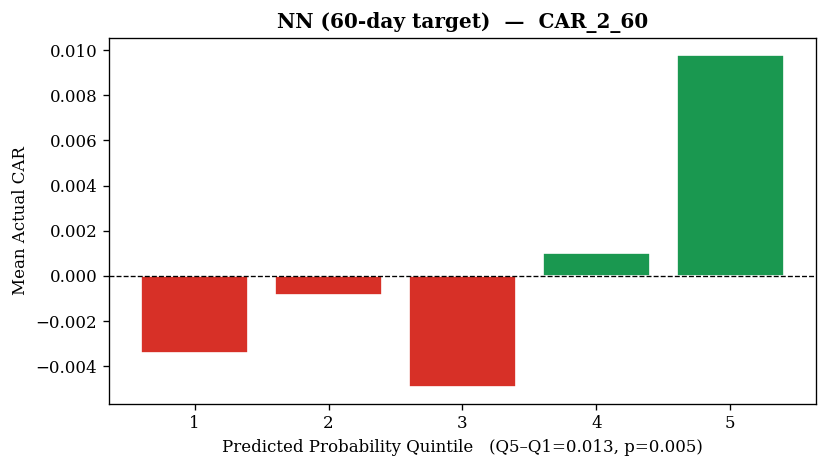

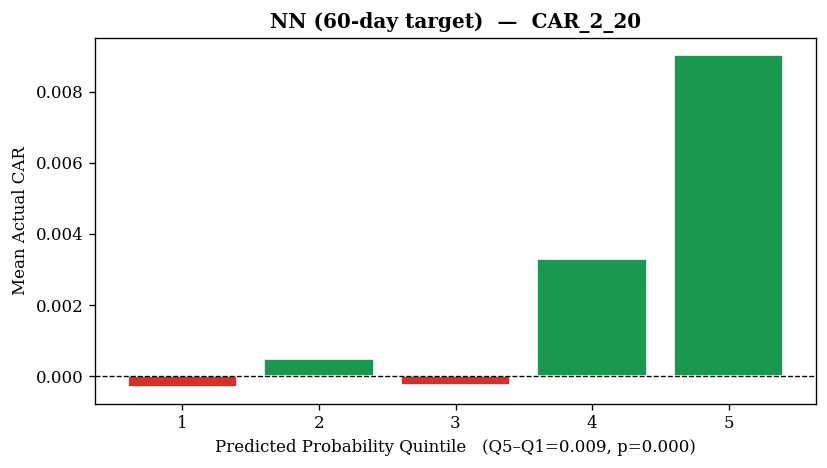

In [ ]:
# Run 60-day NN
nn_proba_60, nn_res_60_60, nn_res_60_20 = run_nn_experiment(
    train['pos_drift'], test['pos_drift'],
    'CAR_2_60', '60-day target'
)

## 12. Full Model Summary

In [ ]:
print('\n' + '='*70)
print(' PEAD PREDICTION SUMMARY — S&P 500 (train ≤ 2020 | test > 2020)')
print('='*70)
print(f'{"Model":<35} {"Target":<12} {"Spread":>8} {"t":>7} {"p":>8}')
print('-'*70)

results = [
    ('Logistic (60-day)',    logit_60_res,   'CAR_2_60'),
    ('Logistic (20-day)',    logit_20_res,   'CAR_2_20'),
    ('EN Logistic (60-day)', en_res_60_60,  'CAR_2_60'),
    ('EN Logistic (60-day)', en_res_60_20,  'CAR_2_20'),
    ('NN (60-day)',           nn_res_60_60,  'CAR_2_60'),
    ('NN (60-day)',           nn_res_60_20,  'CAR_2_20'),
]

for mname, res, target in results:
    print(f'{mname:<35} {target:<12} '
          f'{res["spread"]:>8.4f} {res["t"]:>7.2f} {res["p"]:>8.4f}')

In [ ]:
# Quintile spread bar chart for NN
nn_df = nn_res_60_60['df']
means = nn_df.groupby('q')['CAR_2_60'].mean()
fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#d73027' if v < 0 else '#1a9850' for v in means]
ax.bar(means.index.astype(str), means.values, color=colors, edgecolor='white')
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.set_title('Neural Network — Mean CAR(2,60) by Predicted Probability Quintile', fontweight='bold')
ax.set_xlabel('Predicted Probability Quintile')
ax.set_ylabel('Mean Actual CAR(2,60)')
plt.tight_layout()
plt.show()